# H-Spot — Final Model Result Analysis
**Goal:** Visualize key results for the report and extract global patterns learned by the model.

> Run each cell top-to-bottom. Paste the output back to get interpretation help.

In [16]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Paths ──────────────────────────────────────────────────────────────────
RISK_PATH    = '../../data/processed/results/risk_scores.parquet'
FEATURE_PATH = '../../data/processed/features/model_dataset.parquet'
MODEL_PATH   = '../../models/xgboost_bi_classification.pkl'

# ── Load ───────────────────────────────────────────────────────────────────
df_risk = pd.read_parquet(RISK_PATH)
df_meta = pd.read_parquet(FEATURE_PATH)

with open(MODEL_PATH, 'rb') as f:
    cal_model = pickle.load(f)

# ── Target (same logic as train.py) ────────────────────────────────────────
df_meta['target'] = ((df_meta['acc_fatal'] > 0) | (df_meta['acc_serious'] > 0)).astype(int)

# ── Merge ──────────────────────────────────────────────────────────────────
df = pd.merge(df_risk, df_meta, on='segment_id')

print(f'Segments loaded: {len(df):,}')
print(f'Positive (target=1): {df["target"].sum():,}  ({df["target"].mean()*100:.2f}%)')
print('\nRisk score summary:')
print(df['risk_score'].describe().round(4))

Segments loaded: 277,069
Positive (target=1): 2,613  (0.94%)

Risk score summary:
count    277069.0000
mean          0.0096
std           0.0355
min           0.0000
25%           0.0026
50%           0.0026
75%           0.0051
max           1.0000
Name: risk_score, dtype: float64


## 1  Risk Score Distribution

## 2  Global Feature Importance (XGBoost)

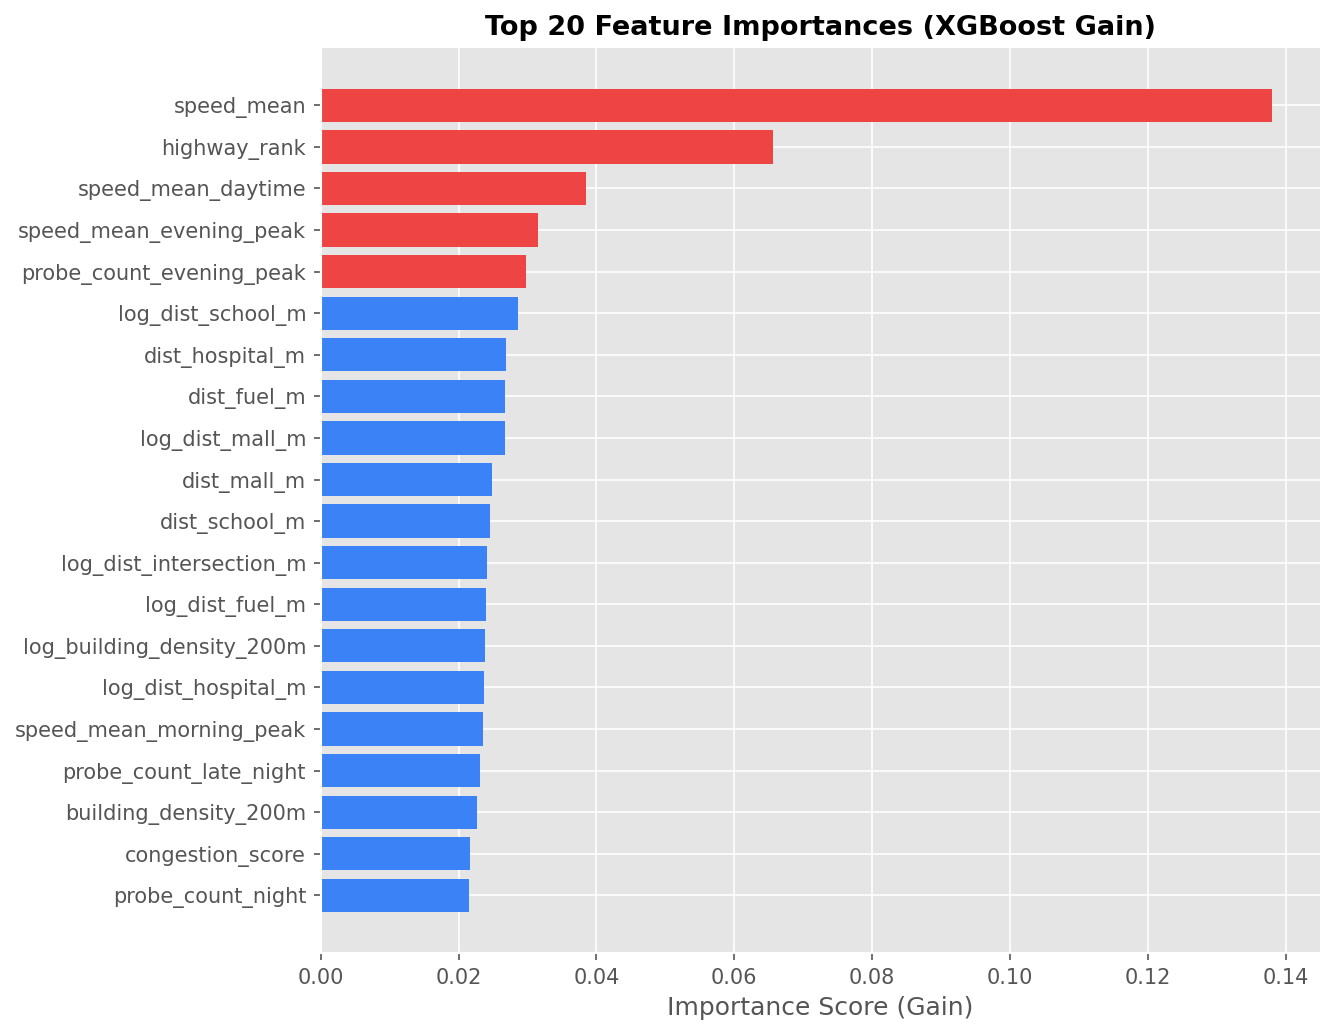


Top 20 features:
speed_mean                   0.1381
highway_rank                 0.0656
speed_mean_daytime           0.0385
speed_mean_evening_peak      0.0315
probe_count_evening_peak     0.0298
log_dist_school_m            0.0286
dist_hospital_m              0.0268
dist_fuel_m                  0.0268
log_dist_mall_m              0.0268
dist_mall_m                  0.0248
dist_school_m                0.0245
log_dist_intersection_m      0.0242
log_dist_fuel_m              0.0240
log_building_density_200m    0.0238
log_dist_hospital_m          0.0238
speed_mean_morning_peak      0.0235
probe_count_late_night       0.0231
building_density_200m        0.0227
congestion_score             0.0216
probe_count_night            0.0215


In [18]:
# Extract the base XGBoost estimator from the calibrated wrapper
base_xgb = cal_model.calibrated_classifiers_[0].estimator

importance = pd.Series(
    base_xgb.feature_importances_,
    index=base_xgb.feature_names_in_
).sort_values(ascending=True)

# Show top 20
top20 = importance.tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#EF4444' if v >= top20.quantile(0.75) else '#3B82F6' for v in top20]
ax.barh(top20.index, top20.values, color=colors, edgecolor='none')
ax.set_title('Top 20 Feature Importances (XGBoost Gain)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score (Gain)')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('fig02_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 20 features:')
print(importance.tail(20).sort_values(ascending=False).round(4).to_string())

## 3  Calibration — Does High Risk Score → More Accidents?

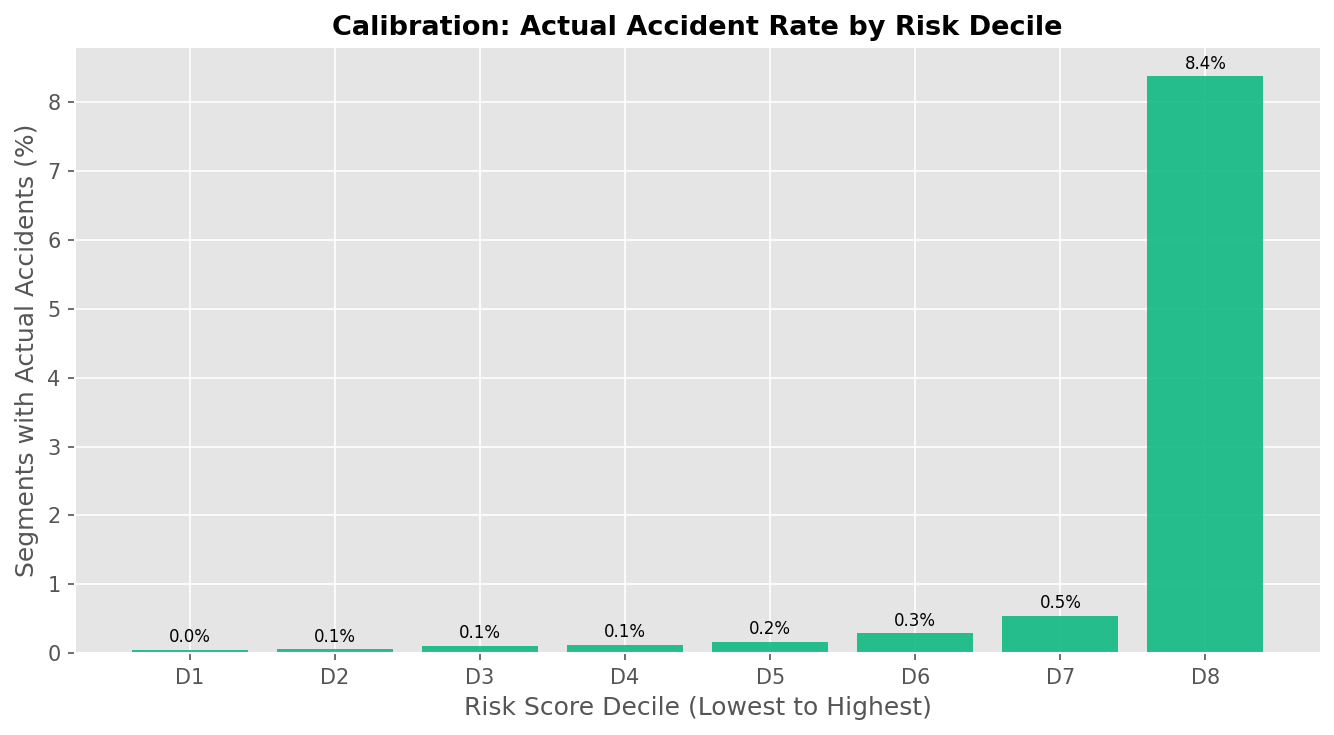

risk_decile  n_segments  accident_rate
         D1       50372       0.000496
         D2       12036       0.000582
         D3       94403       0.001049
         D4       34188       0.001229
         D5       12044       0.001661
         D6       37794       0.002911
         D7        9262       0.005398
         D8       26970       0.083797


In [19]:
# Fix: Dynamically determine number of unique bins to avoid KeyError/ValueError
df['risk_decile'], bins = pd.qcut(df['risk_score'], q=10, retbins=True, duplicates='drop')
num_bins = len(bins) - 1
df['risk_decile'] = pd.qcut(df['risk_score'], q=10, labels=[f'D{i+1}' for i in range(num_bins)], duplicates='drop')

calib = df.groupby('risk_decile', observed=True).agg(
    accident_rate=('target', 'mean'),
    n_segments=('segment_id', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(calib['risk_decile'], calib['accident_rate'] * 100,
              color='#10B981', edgecolor='none', alpha=0.9)
ax.set_title('Calibration: Actual Accident Rate by Risk Decile', fontweight='bold', fontsize=13)
ax.set_xlabel('Risk Score Decile (Lowest to Highest)')
ax.set_ylabel('Segments with Actual Accidents (%)')

for bar, rate in zip(bars, calib['accident_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig03_calibration.png', bbox_inches='tight')
plt.show()

print(calib[['risk_decile','n_segments','accident_rate']].to_string(index=False))

## 4  Pattern: Risk vs Highway Rank
Does road class (rank 1=local, 6=motorway) predict higher risk?

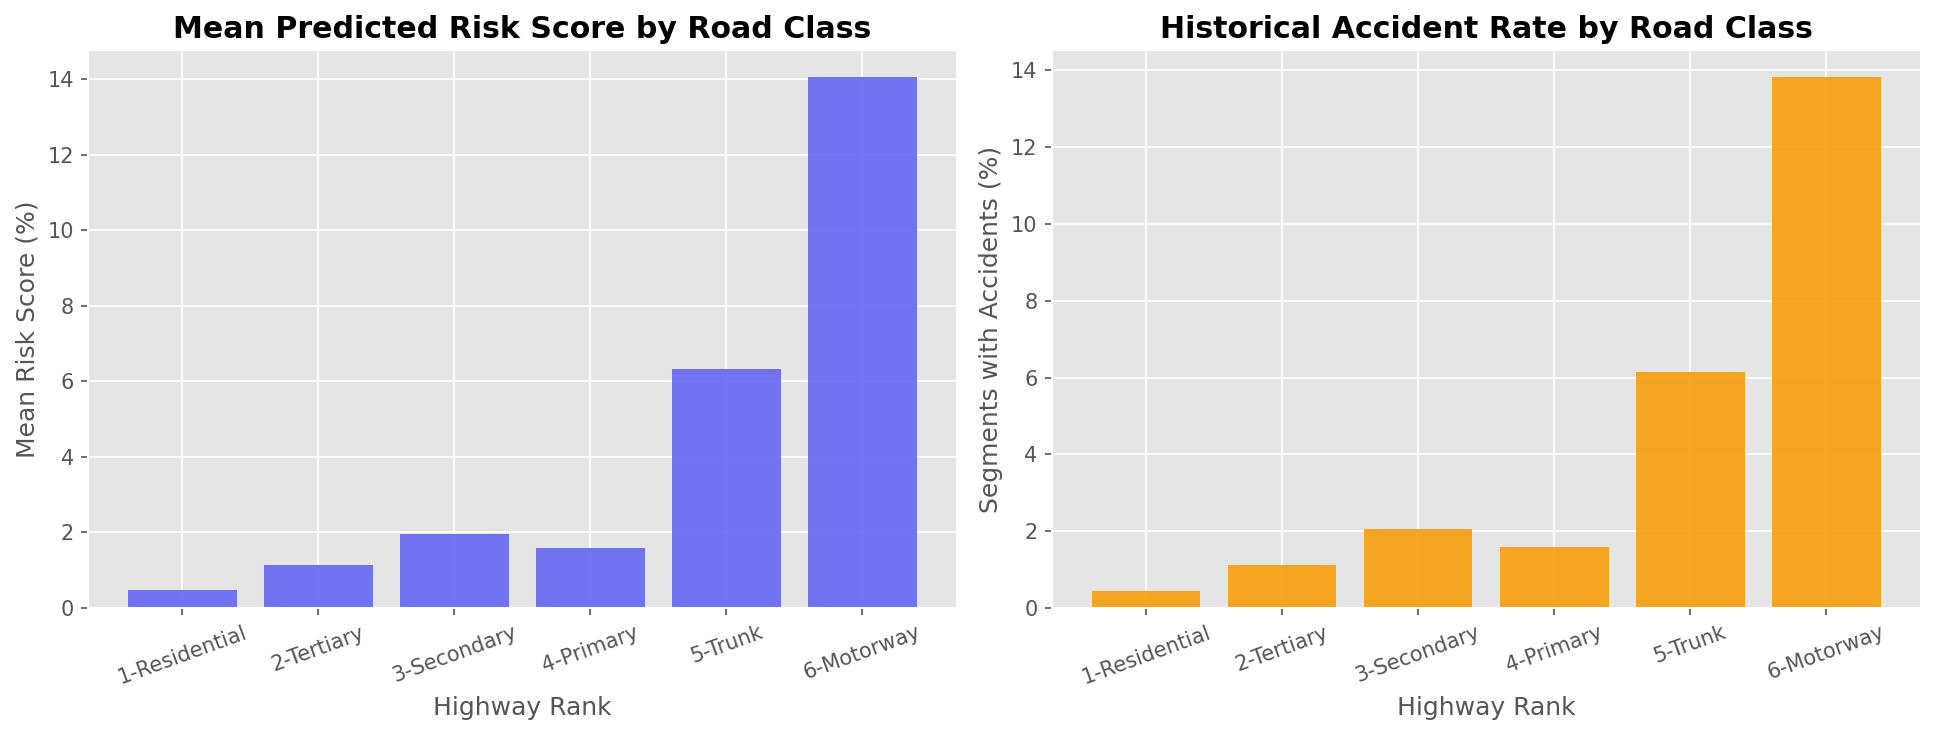


Risk by Road Class:
     hw_label  mean_risk  median_risk  accident_rate  count
1-Residential   0.004701     0.002613       0.004452 227101
   2-Tertiary   0.011233     0.003403       0.011197  12057
  3-Secondary   0.019683     0.008567       0.020587  15592
    4-Primary   0.015729     0.003403       0.015978  12580
      5-Trunk   0.063370     0.022933       0.061533   5233
   6-Motorway   0.140647     0.062195       0.138260   4506


In [20]:
highway_labels = {
    1: '1-Residential',
    2: '2-Tertiary',
    3: '3-Secondary',
    4: '4-Primary',
    5: '5-Trunk',
    6: '6-Motorway',
}
df['hw_label'] = df['highway_rank'].map(highway_labels)

hw_stats = df.groupby('hw_label', observed=True).agg(
    mean_risk=('risk_score', 'mean'),
    median_risk=('risk_score', 'median'),
    accident_rate=('target', 'mean'),
    count=('segment_id', 'count')
).reset_index().sort_values('hw_label')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(hw_stats['hw_label'], hw_stats['mean_risk'] * 100, color='#6366F1', alpha=0.9)
axes[0].set_title('Mean Predicted Risk Score by Road Class', fontweight='bold')
axes[0].set_ylabel('Mean Risk Score (%)')
axes[0].set_xlabel('Highway Rank')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(hw_stats['hw_label'], hw_stats['accident_rate'] * 100, color='#F59E0B', alpha=0.9)
axes[1].set_title('Historical Accident Rate by Road Class', fontweight='bold')
axes[1].set_ylabel('Segments with Accidents (%)')
axes[1].set_xlabel('Highway Rank')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig04_highway_risk.png', bbox_inches='tight')
plt.show()

print('\nRisk by Road Class:')
print(hw_stats.to_string(index=False))

## 5  Pattern: Proactive Risk Segments
Segments the model flags as HIGH RISK but with zero accident history.

Top 1% risk threshold:   0.0977
Total high-risk segs:    2,103
  Validated (has accident): 926 (44.0%)
  Proactive (no accident):  1,177 (56.0%)


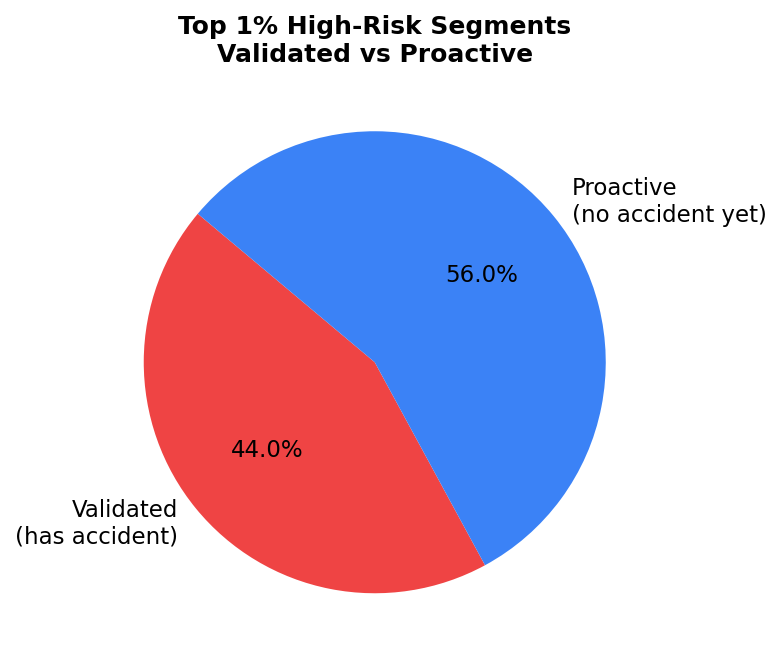


Proactive high-risk segments by road class:
hw_label
6-Motorway       749
5-Trunk          347
3-Secondary       52
4-Primary         22
2-Tertiary         5
1-Residential      2


In [ ]:
threshold_top1pct = df['risk_score'].quantile(0.99)
high_risk = df[df['risk_score'] > threshold_top1pct]

validated  = high_risk[high_risk['target'] == 1]   # Model correct
proactive  = high_risk[high_risk['target'] == 0]   # Model predicts risk, no history yet

print(f'Top 1% risk threshold:   {threshold_top1pct:.4f}')
print(f'Total high-risk segs:    {len(high_risk):,}')
print(f'  Validated (has accident): {len(validated):,} ({len(validated)/len(high_risk)*100:.1f}%)')
print(f'  Proactive (no accident):  {len(proactive):,} ({len(proactive)/len(high_risk)*100:.1f}%)')

# ── Pie chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(
    [len(validated), len(proactive)],
    labels=['Validated\n(has accident)', 'Proactive\n(no accident yet)'],
    colors=['#EF4444', '#3B82F6'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11},
)
ax.set_title('Top 1% High-Risk Segments\nValidated vs Proactive', fontweight='bold', fontsize=12)
plt.savefig('fig05_proactive_pie.png', bbox_inches='tight')
plt.show()

# ── Proactive segments broken down by road class ───────────────────────────
print('\nProactive high-risk segments by road class:')
print(proactive.groupby('hw_label', observed=True)['segment_id'].count().sort_values(ascending=False).to_string())

## 6  Pattern: Congestion vs Risk

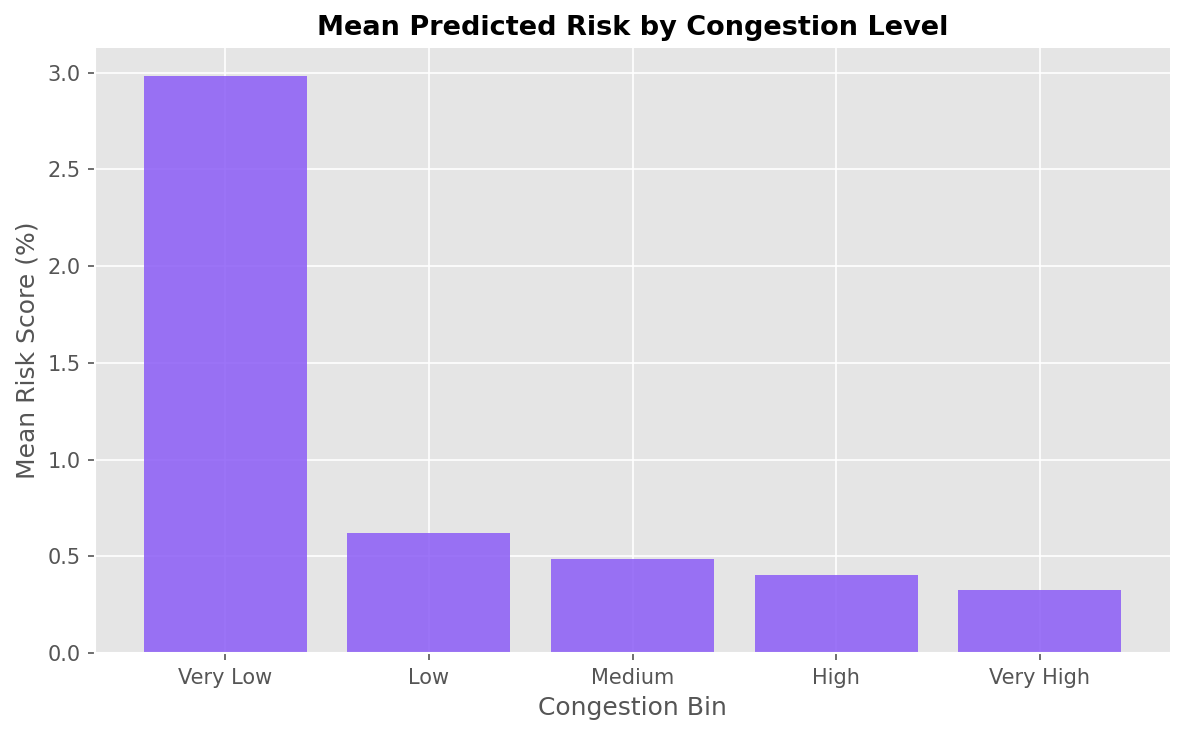


Congestion vs Risk:
congestion_bin  mean_risk  accident_rate  count
      Very Low   0.029815       0.028711  55414
           Low   0.006197       0.006304  56313
        Medium   0.004888       0.004651  56982
          High   0.004038       0.003966  52947
     Very High   0.003244       0.003465  55413


In [22]:
# Fix: Dynamically handle bins for congestion if many segments have identical zero/low scores
df['congestion_bin'], cong_bins = pd.qcut(df['congestion_score'].fillna(0), q=5, retbins=True, duplicates='drop')
num_cong_bins = len(cong_bins) - 1
default_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['congestion_bin'] = pd.qcut(df['congestion_score'].fillna(0), q=5, 
                               labels=default_labels[-num_cong_bins:], 
                               duplicates='drop')

cong_stats = df.groupby('congestion_bin', observed=True).agg(
    mean_risk=('risk_score', 'mean'),
    accident_rate=('target', 'mean'),
    count=('segment_id', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(cong_stats))
ax.bar(x, cong_stats['mean_risk'] * 100, color='#8B5CF6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cong_stats['congestion_bin'])
ax.set_title('Mean Predicted Risk by Congestion Level', fontweight='bold', fontsize=13)
ax.set_ylabel('Mean Risk Score (%)')
ax.set_xlabel('Congestion Bin')
plt.tight_layout()
plt.savefig('fig06_congestion_risk.png', bbox_inches='tight')
plt.show()

print('\nCongestion vs Risk:')
print(cong_stats.to_string(index=False))

## 7  Pattern: Spatial Proximity vs Risk
Does being close to intersections, schools, hospitals raise risk?

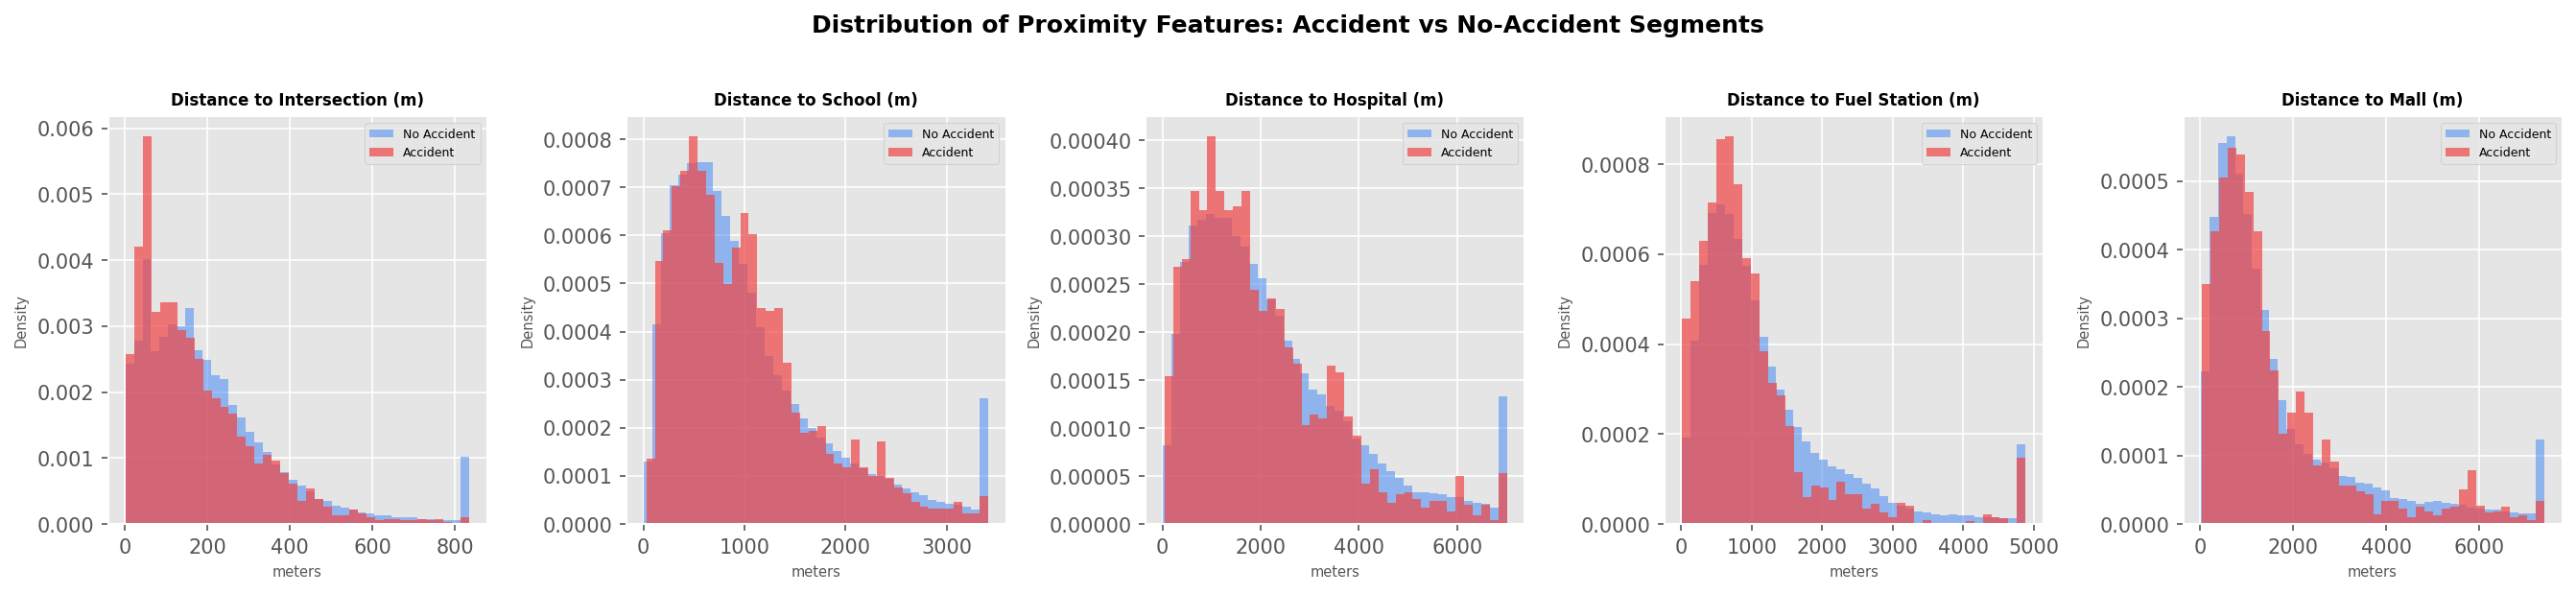

Mean proximity distances (accident=1 vs 0):
target                    0       1
dist_intersection_m   217.8   173.0
dist_school_m        1065.6  1002.5
dist_hospital_m      2249.1  2009.8
dist_fuel_m          1221.7  1003.9
dist_mall_m          1740.5  1589.8


In [25]:
proximity_cols = {
    'dist_intersection_m': 'Distance to Intersection (m)',
    'dist_school_m':       'Distance to School (m)',
    'dist_hospital_m':     'Distance to Hospital (m)',
    'dist_fuel_m':         'Distance to Fuel Station (m)',
    'dist_mall_m':         'Distance to Mall (m)',
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (col, label) in zip(axes, proximity_cols.items()):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    low_risk  = df[df['target'] == 0][col].clip(upper=df[col].quantile(0.98))
    high_risk = df[df['target'] == 1][col].clip(upper=df[col].quantile(0.98))
    ax.hist(low_risk,  bins=40, alpha=0.5, color='#3B82F6', label='No Accident', density=True)
    ax.hist(high_risk, bins=40, alpha=0.7, color='#EF4444', label='Accident', density=True)
    ax.set_title(label, fontsize=8, fontweight='bold')
    ax.set_xlabel('meters', fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.legend(fontsize=6)

plt.suptitle('Distribution of Proximity Features: Accident vs No-Accident Segments',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig07_proximity_patterns.png', bbox_inches='tight')
plt.show()

# Numeric summary
print('Mean proximity distances (accident=1 vs 0):')
cols_exist = [c for c in proximity_cols if c in df.columns]
print(df.groupby('target')[cols_exist].mean().round(1).T.to_string())

## 8  Summary Table — Key Numbers for the Report

In [24]:
print('=' * 55)
print('  KEY RESULTS FOR REPORT')
print('=' * 55)
print(f'  Total segments scored:          {len(df):>10,}')
print(f'  Segments with accident history: {df["target"].sum():>10,}  ({df["target"].mean()*100:.2f}%)')
print()
print(f'  Risk > 10%:                     {(df["risk_score"] > 0.10).sum():>10,}')
print(f'  Risk > 50%:                     {(df["risk_score"] > 0.50).sum():>10,}')
print(f'  Risk > 80%:                     {(df["risk_score"] > 0.80).sum():>10,}')
print()
print(f'  Top 1% threshold:               {df["risk_score"].quantile(0.99):>10.4f}')
print(f'  Proactive high-risk segs:       {len(proactive):>10,}')
print(f'  Validated high-risk segs:       {len(validated):>10,}')
print('=' * 55)

  KEY RESULTS FOR REPORT
  Total segments scored:             277,069
  Segments with accident history:      2,613  (0.94%)

  Risk > 10%:                          2,103
  Risk > 50%:                            174
  Risk > 80%:                             27

  Top 1% threshold:                   0.0977
  Proactive high-risk segs:            1,177
  Validated high-risk segs:              926
